In [2]:
import os
from pathlib import Path

# Get the current directory of the notebook
notebook_path = Path.cwd()

ROOT = notebook_path.parent.parent

# Change the Working Directory for the whole process
os.chdir(ROOT)

print(f"Current Working Directory fixed to: {os.getcwd()}")

Current Working Directory fixed to: /srv/homes/onbo10/thesis_main


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import yaml


Analyzing RGB intensities in 180 images...


100%|██████████| 180/180 [00:13<00:00, 13.29it/s]


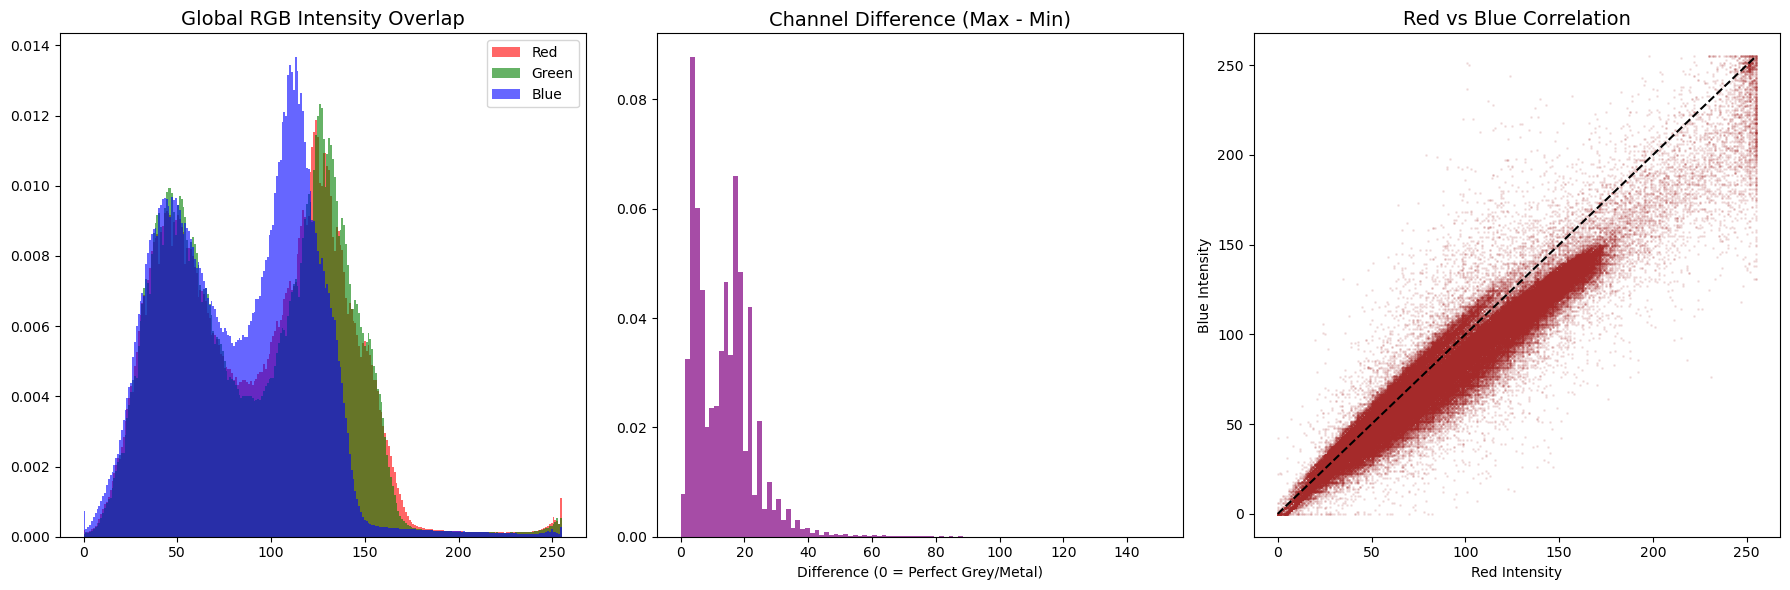

In [82]:

def plot_global_rgb_distributions(img_dir, pred_dir):
    
    all_r, all_g, all_b = [], [], []
    all_diff = [] # Max(RGB) - Min(RGB)

    pred_files = [f for f in os.listdir(pred_dir) if f.endswith('.png')]
    print(f"Analyzing RGB intensities in {len(pred_files)} images...")

    for pred_name in tqdm(pred_files):
        base_name = os.path.splitext(pred_name)[0]
        img_path = os.path.join(img_dir, f"{base_name}_0000.png")
        pred_path = os.path.join(pred_dir, pred_name)

        if not os.path.exists(img_path):
            continue

        # Load image (Convert BGR to RGB) and Mask
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(pred_path, cv2.IMREAD_GRAYSCALE)

        # Extract RGB values from the predicted positive area
        pixels = img_rgb[mask > 0].astype(np.int32)

        if pixels.size > 0:
            all_r.extend(pixels[:, 0])
            all_g.extend(pixels[:, 1])
            all_b.extend(pixels[:, 2])
            
            # Calculate Spectral Neutrality: Max - Min
            # Metals stay near 0; Tinted tissue has high differences
            diffs = np.max(pixels, axis=1) - np.min(pixels, axis=1)
            all_diff.extend(diffs)

    # Convert to numpy for plotting
    all_r, all_g, all_b, all_diff = map(np.array, [all_r, all_g, all_b, all_diff])

  
    fig, axes = plt.subplots(1,3 ,figsize=(18, 6))
    
    #Individual Channel Distributions
    axes[0].hist(all_r, bins=256, range=(0, 255), color='red', alpha=0.6, label='Red', density=True)
    axes[0].hist(all_g, bins=256, range=(0, 255), color='green', alpha=0.6, label='Green', density=True)
    axes[0].hist(all_b, bins=256, range=(0, 255), color='blue', alpha=0.6, label='Blue', density=True)
    axes[0].set_title('Global RGB Intensity Overlap', fontsize=14)
    axes[0].legend()

    #Channel Difference (The "Neutrality" Filter)
    axes[1].hist(all_diff, bins=100, range=(0,150), color='purple', alpha=0.7, density=True)
    axes[1].set_title('Channel Difference (Max - Min)', fontsize=14)
    axes[1].set_xlabel('Difference (0 = Perfect Grey/Metal)')

    #Red vs Blue Relationship
    axes[2].scatter(all_r[::100], all_b[::100], alpha=0.1, s=1, color='brown') # Subsampled for speed
    axes[2].plot([0, 255], [0, 255], 'k--') # Identity line (where R=B)
    axes[2].set_title('Red vs Blue Correlation', fontsize=14)
    axes[2].set_xlabel('Red Intensity')
    axes[2].set_ylabel('Blue Intensity')

  
    plt.tight_layout()
    #plt.savefig('global_rgb_analysis.png', dpi=300)
    plt.show()

# --- EXECUTION ---
IMG_DIR = 'data/EndoVis2017/Surgpose_for_nnUnet_test/imagesTs'
PRED_DIR = 'results/Segmentation/nnunet_results/nnUnet_inference/Surgpose_all_folds'

plot_global_rgb_distributions(IMG_DIR, PRED_DIR)

### Colour spectral neutrality + R/B <1 ~ gray (tool)

In [79]:

class RGBNeutralityProcessor:
    def __init__(self, diff_threshold=25, rb_ratio_limit=1.2):
        """
        diff_threshold: Max difference allowed between RGB channels.
        rb_ratio_limit: Maximum allowed Red/Blue ratio to filter out fleshy tones.
        """
        self.diff_threshold = diff_threshold
        self.rb_ratio_limit = rb_ratio_limit

    def apply_filter(self, image_rgb, mask):
       
        img = image_rgb.astype(np.int32)
        r, g, b = img[:,:,0], img[:,:,1], img[:,:,2]

        #Calculate Spectral Difference (Max-Min)
        max_val = np.max(img, axis=2)
        min_val = np.min(img, axis=2)
        diff = max_val - min_val

        #Calculate Red/Blue Ratio
 
        rb_ratio = r / (b + 1e-5)

       
        # Instrument should have low difference AND balanced R/B ratio
        is_neutral = (diff <= self.diff_threshold) & (rb_ratio <= self.rb_ratio_limit)

        #Clean the pred
        cleaned_mask = mask.copy()
        cleaned_mask[~is_neutral] = 0 # Remove pixels that are not neutral

        
        kernel = np.ones((3,3), np.uint8)
        cleaned_mask = cv2.morphologyEx(cleaned_mask, cv2.MORPH_OPEN, kernel)

        return cleaned_mask



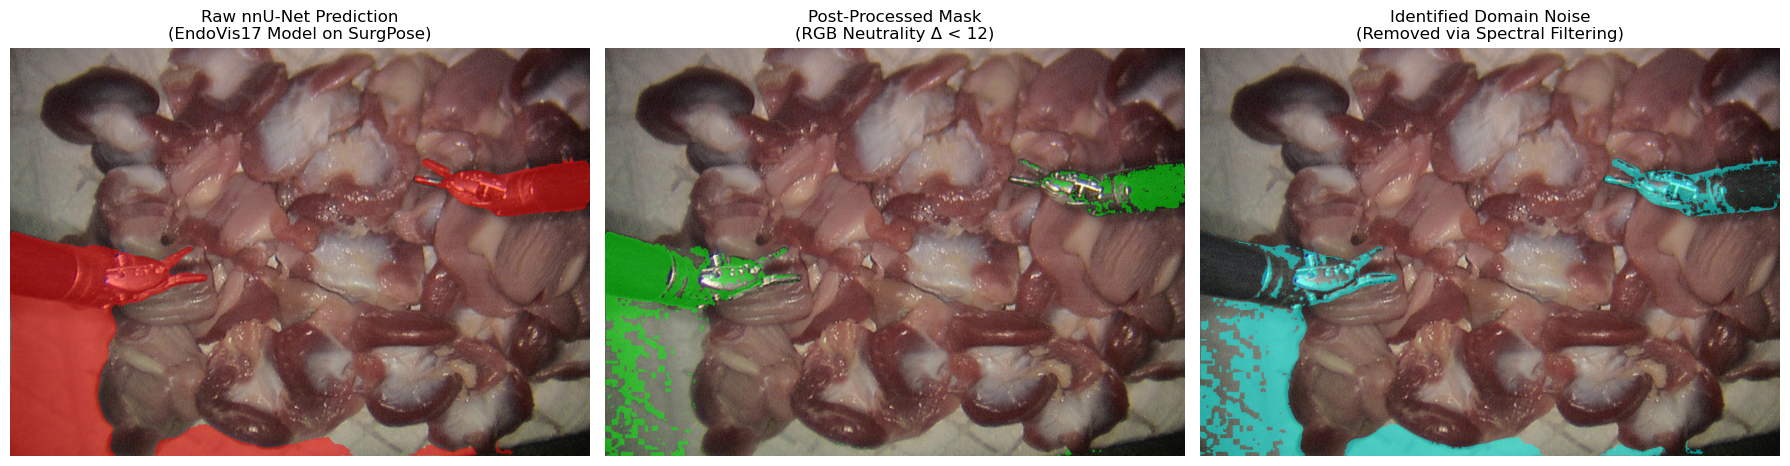

In [42]:

def plot_thesis_comparison(img_path, pred_path, threshold=10,rb_ratio_limit=1.2):
    processor = RGBNeutralityProcessor(diff_threshold=threshold)
    
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    raw_mask = cv2.imread(pred_path, cv2.IMREAD_GRAYSCALE)

    cleaned_mask = processor.apply_filter(img_rgb, raw_mask)
    
    
    def apply_overlay(img, mask, color, alpha=0.5):
        overlay = img.copy()
        if mask is not None and np.any(mask > 0):
            region = mask > 0
            overlay[region] = (overlay[region] * (1 - alpha) + np.array(color) * alpha).astype(np.uint8)
        return overlay

    raw_overlay = apply_overlay(img_rgb, raw_mask, [255, 0, 0])      
    clean_overlay = apply_overlay(img_rgb, cleaned_mask, [0, 255, 0]) 
    removed_mask = (raw_mask > 0) & (cleaned_mask == 0)
    diff_overlay = apply_overlay(img_rgb, removed_mask.astype(np.uint8), [0, 255, 255]) 

  
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(raw_overlay)
    axes[0].set_title("Raw nnU-Net Prediction\n(EndoVis17 Model on SurgPose)", fontsize=12)
    
    axes[1].imshow(clean_overlay)
    axes[1].set_title(f"Post-Processed Mask\n(RGB Neutrality Δ < {threshold})", fontsize=12)
    
    axes[2].imshow(diff_overlay)
    axes[2].set_title("Identified Domain Noise\n(Removed via Spectral Filtering)", fontsize=12)

    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()


sp_pred_path='results/Segmentation/nnunet_results/nnUnet_inference/Surgpose_all_folds/sp_000001_frame_000342.png'
sp_img_path ='data/EndoVis2017/Surgpose_for_nnUnet_test/imagesTs/sp_000001_frame_000342_0000.png'
plot_thesis_comparison(sp_img_path, sp_pred_path, threshold=12,rb_ratio_limit=1)

In [80]:
def process_dataset_with_neutrality(pred_dir, img_dir, output_dir, diff_thresh=12, rb_limit=1.0):
    """
    Applies the RGBNeutralityProcessor logic to the entire dataset.
    """
    processor = RGBNeutralityProcessor(diff_threshold=diff_thresh, rb_ratio_limit=rb_limit)
    
    os.makedirs(output_dir, exist_ok=True)
    
    pred_files = [f for f in os.listdir(pred_dir) if f.endswith('.png')]
    print(f"Refining {len(pred_files)} masks using Spectral Neutrality...")
    print(f"Params: Diff < {diff_thresh}, R/B Ratio < {rb_limit}")

    for pred_name in tqdm(pred_files):
        # Path Matching
        base_name = os.path.splitext(pred_name)[0]
        img_path = os.path.join(img_dir, f"{base_name}_0000.png")
        pred_path = os.path.join(pred_dir, pred_name)
        output_path = os.path.join(output_dir, pred_name)

        if not os.path.exists(img_path):
            continue

        # Load Data
        img_bgr = cv2.imread(img_path)
        raw_mask = cv2.imread(pred_path, cv2.IMREAD_GRAYSCALE)
        
        if img_bgr is None or raw_mask is None:
            continue
            
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # Apply the Class-based filter
        refined_mask = processor.apply_filter(img_rgb, raw_mask)

        # Save result
        cv2.imwrite(output_path, refined_mask)

    print(f"\nSpectral filtering complete. Results saved to: {output_dir}")


NEUTRAL_DIR = 'results/Segmentation/nnunet_results/nnUnet_inference/Refined_Neutrality_Masks'
IMG_DIR = 'data/EndoVis2017/Surgpose_for_nnUnet_test_left_right/imagesTs'
PRED_DIR ='results/Segmentation/nnunet_results/nnUnet_inference/Surgpose_all_folds_left_right'

process_dataset_with_neutrality(PRED_DIR, IMG_DIR, NEUTRAL_DIR, diff_thresh=12, rb_limit=1.0)

Refining 180 masks using Spectral Neutrality...
Params: Diff < 12, R/B Ratio < 1.0


100%|██████████| 180/180 [00:18<00:00, 10.00it/s]


Spectral filtering complete. Results saved to: results/Segmentation/nnunet_results/nnUnet_inference/Refined_Neutrality_Masks


### Edge detection and mask refinement 

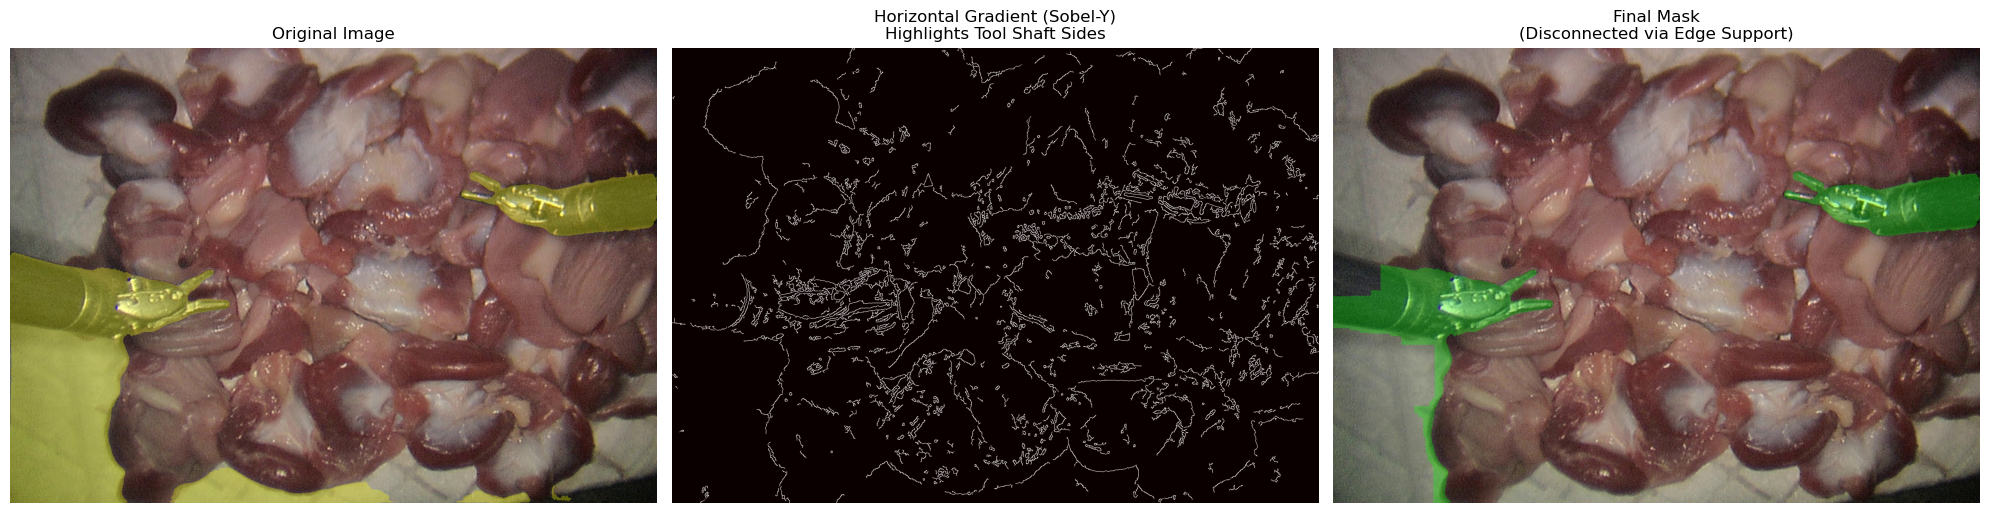

In [77]:

def edge_based_filter(img_rgb, mask):
   
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    # Increase contrast on the L channel 
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8,8))
    l = clahe.apply(l)
    aligned_lab = cv2.merge((l, a, b))
    aligned_bgr = cv2.cvtColor(aligned_lab, cv2.COLOR_LAB2BGR)
    gray= cv2.cvtColor(aligned_bgr, cv2.COLOR_BGR2GRAY)
    
    gray = cv2.GaussianBlur(gray, (5, 5), 0) # Reduce noise
    
    #Use Canny edge detector
    edges = cv2.Canny(gray, 70,200)
    
  
    # Create a safe zone, dialate a lot to connect close edges
    kernel = np.ones((15,15), np.uint8)
    safe_zone = cv2.dilate(edges, kernel, iterations=1)
    
    # Close the gaps to make the safe_zone a solid silhouette
    safe_zone = cv2.morphologyEx(safe_zone, cv2.MORPH_CLOSE, kernel, iterations=5)
    
    #Get the intersection
    refined_mask = cv2.bitwise_and(mask.astype(np.uint8), safe_zone)
 
    #Component selection
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(refined_mask)
    final_output = np.zeros_like(refined_mask)
    
    if num_labels > 1:
        areas = stats[1:, cv2.CC_STAT_AREA]
        max_area = np.max(areas)
        for i, area in enumerate(areas):
            if area > (max_area * 0.3): # Keep anything significant
                final_output[labels == i + 1] = 255
                
    return final_output, edges

def plot_edge_results(img_path, pred_path):
    img_rgb = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    raw_mask = cv2.imread(pred_path, cv2.IMREAD_GRAYSCALE)

    cleaned, edges = edge_based_filter(img_rgb, raw_mask)

    fig, axes = plt.subplots(1, 3, figsize=(20, 8))
    overlay_mask = img_rgb.copy()
    axes[0].imshow(img_rgb)
    overlay_mask[raw_mask > 0] = [255, 255, 0]
    axes[0].imshow(cv2.addWeighted(img_rgb, 0.7, overlay_mask, 0.3, 0))
    axes[0].set_title("Original Image")
    
    axes[1].imshow(edges, cmap='hot')
    axes[1].set_title("Horizontal Gradient (Sobel-Y)\nHighlights Tool Shaft Sides")
    
    # Show the final result with overlay
    overlay = img_rgb.copy()
    overlay[cleaned > 0] = [0, 255, 0]
    axes[2].imshow(cv2.addWeighted(img_rgb, 0.7, overlay, 0.3, 0))
    axes[2].set_title("Final Mask\n(Disconnected via Edge Support)")

    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

# IMG_PATH = 'data/EndoVis2017/Surgpose_for_nnUnet_test/imagesTs/sp_000017_frame_000045_0000.png'
# PRED_PATH = 'results/Segmentation/nnunet_results/nnUnet_inference/Surgpose_all_folds/sp_000017_frame_000045.png'

IMG_PATH = 'data/EndoVis2017/Surgpose_for_nnUnet_test/imagesTs/sp_000001_frame_000342_0000.png'
PRED_PATH = 'results/Segmentation/nnunet_results/nnUnet_inference/Surgpose_all_folds/sp_000001_frame_000342.png'
plot_edge_results(IMG_PATH, PRED_PATH)

In [76]:

def process_dataset_with_edges(pred_dir, img_dir, output_dir):
    """
    Runs the edge_based_filter on all masks in the pred_dir.
    Matches sp_xxx.png (mask) to sp_xxx_0000.png (raw image).
    """
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    # Get all prediction masks
    pred_files = [f for f in os.listdir(pred_dir) if f.endswith('.png')]
    print(f"Refining {len(pred_files)} masks using Edge-Based Support...")

    for pred_name in tqdm(pred_files):
     
        base_name = os.path.splitext(pred_name)[0]
        img_path = os.path.join(img_dir, f"{base_name}_0000.png")
        pred_path = os.path.join(pred_dir, pred_name)
        output_path = os.path.join(output_dir, pred_name)

        if not os.path.exists(img_path):
            # Fallback check: try without the _0000 suffix just in case
            img_path = os.path.join(img_dir, f"{base_name}.png")
            if not os.path.exists(img_path):
                continue

        #Load Data
        img_bgr = cv2.imread(img_path)
        raw_mask = cv2.imread(pred_path, cv2.IMREAD_GRAYSCALE)
        
        if img_bgr is None or raw_mask is None:
            continue
            
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        #Apply the Filter
        # Using your edge_based_filter function
        refined_mask, _ = edge_based_filter(img_rgb, raw_mask)

        # 4. Save the result
        cv2.imwrite(output_path, refined_mask)

    print(f"\nProcessing complete. Refined masks saved to: {output_dir}")


IMG_DIR = 'data/EndoVis2017/Surgpose_for_nnUnet_test_left_right/imagesTs'
PRED_DIR ='results/Segmentation/nnunet_results/nnUnet_inference/Surgpose_all_folds_left_right'
REFINED_DIR = 'results/Segmentation/nnunet_results/nnUnet_inference/Refined_Edge_Masks'

process_dataset_with_edges(PRED_DIR, IMG_DIR, REFINED_DIR)

Refining 180 masks using Edge-Based Support...


100%|██████████| 180/180 [00:09<00:00, 18.32it/s]


Processing complete. Refined masks saved to: results/Segmentation/nnunet_results/nnUnet_inference/Refined_Edge_Masks


### Edge based disconnection

In [33]:
def edge_cutter_filter(img_rgb, mask):
    #high-contrast preprocessing
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    gray = cv2.cvtColor(cv2.cvtColor(cv2.merge((l,a,b)), cv2.COLOR_LAB2BGR), cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    #Detect Edges 
    edges = cv2.Canny(gray, 80,200)
    
    #Thicken the edges slightly 
 
    kernel_cut = np.ones((3,3), np.uint8)
    thick_edges = cv2.dilate(edges, kernel_cut, iterations=1)
    
   
    edge_inverse = cv2.bitwise_not(thick_edges)
    
    #Cut the prediction mask
    # This physically separates the tool from the leaking tissue
    cut_mask = cv2.bitwise_and(mask.astype(np.uint8), edge_inverse)
    
    #Component Selection 
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(cut_mask)
    final_output = np.zeros_like(cut_mask)
    
    if num_labels > 1:
        # Sort by area, ignoring background (index 0)
        areas = stats[1:, cv2.CC_STAT_AREA]
        max_area = np.max(areas)
        for i, area in enumerate(areas):
            # Only keep blobs that are substantial
            if area > (max_area * 0.2):
                final_output[labels == i + 1] = 255
    

    # Because we cut through the mask, the tool now has a 1-pixel black border.
    # We dilate slightly to close those thin "cuts" back up.
    final_output = cv2.dilate(final_output, kernel_cut, iterations=1)
    final_output = cv2.bitwise_and(final_output, mask) # Ensure we don't go outside original prediction

    return final_output, thick_edges

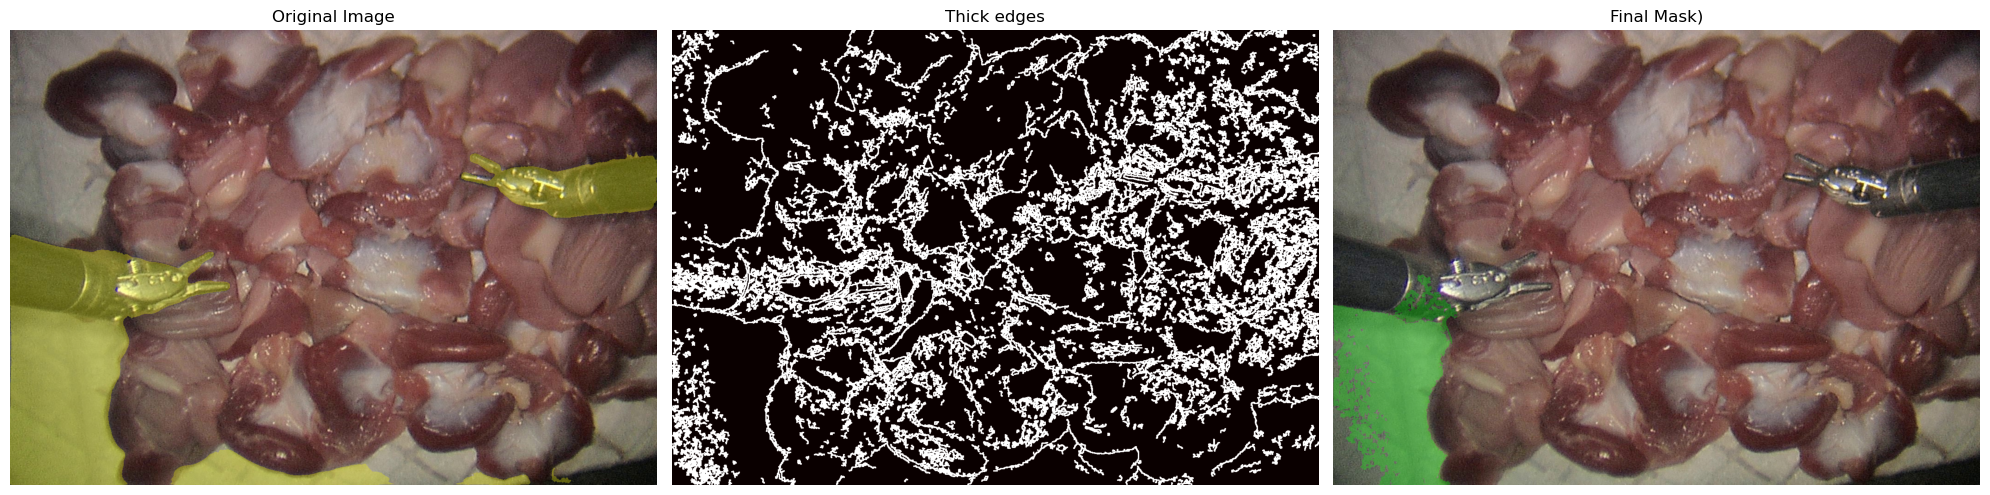

In [34]:
def plot_edge_results(img_path, pred_path):
    img_rgb = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    raw_mask = cv2.imread(pred_path, cv2.IMREAD_GRAYSCALE)

    cleaned, edges = edge_cutter_filter(img_rgb, raw_mask)

    fig, axes = plt.subplots(1, 3, figsize=(20, 8))
    overlay_mask = img_rgb.copy()
    axes[0].imshow(img_rgb)
    overlay_mask[raw_mask > 0] = [255, 255, 0]
    axes[0].imshow(cv2.addWeighted(img_rgb, 0.7, overlay_mask, 0.3, 0))
    axes[0].set_title("Original Image")
    
    axes[1].imshow(edges, cmap='hot')
    axes[1].set_title("Thick edges")
    
    # Show the final result with overlay
    overlay = img_rgb.copy()
    overlay[cleaned > 0] = [0, 255, 0]
    axes[2].imshow(cv2.addWeighted(img_rgb, 0.7, overlay, 0.3, 0))
    axes[2].set_title("Final Mask)")

    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

# IMG_PATH = 'data/EndoVis2017/Surgpose_for_nnUnet_test/imagesTs/sp_000017_frame_000045_0000.png'
# PRED_PATH = 'results/Segmentation/nnunet_results/nnUnet_inference/Surgpose_all_folds/sp_000017_frame_000045.png'

IMG_PATH = 'data/EndoVis2017/Surgpose_for_nnUnet_test/imagesTs/sp_000001_frame_000342_0000.png'
PRED_PATH = 'results/Segmentation/nnunet_results/nnUnet_inference/Surgpose_all_folds/sp_000001_frame_000342.png'
plot_edge_results(IMG_PATH, PRED_PATH)

In [24]:
import numpy as np
import cv2

def bbox_strict_selection(refined_mask, bboxes):
    """
    Only keeps a component if its entire bounding box is contained 
    within the ground truth bounding box.
    """
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(refined_mask)
    final_output = np.zeros_like(refined_mask)
    
    for i in range(1, num_labels):
        # Component boundaries
        c_x1 = stats[i, cv2.CC_STAT_LEFT]
        c_y1 = stats[i, cv2.CC_STAT_TOP]
        c_w  = stats[i, cv2.CC_STAT_WIDTH]
        c_h  = stats[i, cv2.CC_STAT_HEIGHT]
        c_x2 = c_x1 + c_w
        c_y2 = c_y1 + c_h
        
        # Check if this component is COMPLETELY inside ANY ground truth bbox
        is_contained = False
        for bbox in bboxes:
            bx1, by1, bx2, by2 = bbox
            
            #Component boundaries must be within GT boundaries
            if (c_x1 >= bx1 and c_y1 >= by1 and 
                c_x2 <= bx2 and c_y2 <= by2):
                is_contained = True
                break 
        
        if is_contained:
            final_output[labels == i] = 255
            
    return final_output

def edge_cutter_with_bbox(img_rgb, mask, bboxes):
    #Preprocessing Contrast enhancement (LAB + CLAHE)
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8,8))
    l = clahe.apply(l)
    gray = cv2.cvtColor(cv2.cvtColor(cv2.merge((l,a,b)), cv2.COLOR_LAB2BGR), cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    #Detect the edges
    edges = cv2.Canny(gray, 70, 200)
    
    #Create the Cut
    kernel_cut = np.ones((3,3), np.uint8)
    thick_edges = cv2.dilate(edges, kernel_cut, iterations=1)
    edge_inverse = cv2.bitwise_not(thick_edges)
    
    #Physically Disconnect the prediction
    cut_mask = cv2.bitwise_and(mask.astype(np.uint8), edge_inverse)
    
    final_output= bbox_strict_selection(cut_mask,bboxes)
    kernel_dialate = np.ones((15,15), np.uint8)
    final_output = cv2.dilate(final_output, kernel_dialate, iterations=4)
    final_output = cv2.bitwise_and(final_output, mask) # Stay within original AI boundary

    return final_output, thick_edges

In [26]:
import os
import cv2
import yaml
import numpy as np
from tqdm import tqdm

def process_dataset_with_bbox_edge_cut(pred_dir, img_dir, yaml_dir, output_dir):
    """
    Iterates through predictions, matches them with YAML bboxes, 
    and applies the edge-cutting refinement.
    """
    os.makedirs(output_dir, exist_ok=True)
    
    # Get list of prediction files (nnU-Net outputs)
    pred_files = [f for f in os.listdir(pred_dir) if f.endswith('.png')]
    print(f"Refining {len(pred_files)} masks using Edge-Cut + BBox Support...")

    for pred_name in tqdm(pred_files):
        # Filename Matching
       
        base_name = os.path.splitext(pred_name)[0]
        img_path = os.path.join(img_dir, f"{base_name}_0000.png")
        yaml_path = os.path.join(yaml_dir, f"{base_name}.yaml")
        pred_path = os.path.join(pred_dir, pred_name)
        output_path = os.path.join(output_dir, pred_name)

        #Load YAML and Extract Bounding Boxes
        if not os.path.exists(yaml_path):
            print(f"Warning: No YAML found for {base_name}. Skipping refinement.")
            continue
            
        with open(yaml_path, 'r') as f:
            data = yaml.safe_load(f)
        
        # Extract bboxes: [[x1, y1, x2, y2], ...]
        bboxes = []
        if 'objects' in data:
            for obj in data['objects']:
                if 'bbox' in obj and obj['bbox'] is not None:
                    bboxes.append(obj['bbox'])
        
        # Load Image and Mask
        img_bgr = cv2.imread(img_path)
        raw_mask = cv2.imread(pred_path, cv2.IMREAD_GRAYSCALE)
        
        if img_bgr is None or raw_mask is None:
            continue
            
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        
        refined_mask, _ = edge_cutter_with_bbox(img_rgb, raw_mask, bboxes)

      
        cv2.imwrite(output_path, refined_mask)

    print(f"\nSuccess! Refined masks saved to: {output_dir}")


IMG_SOURCE = 'data/EndoVis2017/Surgpose_for_nnUnet_test_left_right/imagesTs'
PRED_INPUT = '/srv/homes/onbo10/thesis_main/results/Segmentation/nnunet_results/nnUnet_inference/Surgpose_all_folds_left_right'
BBOX_YAML_DIR = '/srv/homes/onbo10/thesis_main/data/EndoVis2017/Surgpose_for_nnUnet_test_left_right/bboxesTs'
FINAL_OUTPUT = 'results/Segmentation/nnunet_results/nnUnet_inference/Refined_EdgeCut_BBox'


process_dataset_with_bbox_edge_cut(PRED_INPUT, IMG_SOURCE, BBOX_YAML_DIR, FINAL_OUTPUT)

Refining 180 masks using Edge-Cut + BBox Support...


100%|██████████| 180/180 [00:25<00:00,  7.09it/s]


Success! Refined masks saved to: results/Segmentation/nnunet_results/nnUnet_inference/Refined_EdgeCut_BBox


### Refine masks using bboxes

In [73]:

def apply_bbox_constraint(mask, bbox_list, img_shape):
    """
    Creates a 'safe zone' from bounding boxes and intersects it with the mask.
    bbox_list: list of [xmin, ymin, xmax, ymax]
    """
   
    bbox_mask = np.zeros(img_shape[:2], dtype=np.uint8)
    
    for bbox in bbox_list:
        x1, y1, x2, y2 = map(int, bbox)
        cv2.rectangle(bbox_mask, (x1, y1), (x2, y2), 255, -1)
    
    #keep pixels in mask and in bbox
    refined_mask = cv2.bitwise_and(mask, bbox_mask)
    return refined_mask

def process_all_predictions(pred_dir, yaml_dir, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    
    
    pred_files = [f for f in os.listdir(pred_dir) if f.endswith('.png')]
    
    print(f"Refining {len(pred_files)} predictions using BBox constraints...")
    
    for pred_name in tqdm(pred_files):
        #Load Prediction Mask
        pred_path = os.path.join(pred_dir, pred_name)
        mask = cv2.imread(pred_path, cv2.IMREAD_GRAYSCALE)
        
        base_name = pred_name.replace('_0000.png', '').replace('.png', '')
        yaml_path = os.path.join(yaml_dir, f"{base_name}.yaml")
        
        if not os.path.exists(yaml_path):
            # If no bbox exists, we might want to keep the mask or clear it
            # Here we just save the original mask
            cv2.imwrite(os.path.join(output_dir, pred_name), mask)
            continue
            
        #Extract bboxes from yaml
        with open(yaml_path, 'r') as f:
            data = yaml.safe_load(f)
        
        bboxes = [obj['bbox'] for obj in data.get('objects', []) if obj.get('bbox')]
        
        #Apply the refined mask
        refined = apply_bbox_constraint(mask, bboxes, mask.shape)
        
        #Save Refined Mask
        cv2.imwrite(os.path.join(output_dir, pred_name), refined)


PRED_INPUT = '/srv/homes/onbo10/thesis_main/results/Segmentation/nnunet_results/nnUnet_inference/Surgpose_all_folds_left_right'
BBOX_YAML_DIR = '/srv/homes/onbo10/thesis_main/data/EndoVis2017/Surgpose_for_nnUnet_test_left_right/bboxesTs'
FINAL_OUTPUT = 'results/Segmentation/nnunet_results/nnUnet_inference/Refined_BBox_Masks'

process_all_predictions(PRED_INPUT, BBOX_YAML_DIR, FINAL_OUTPUT)

Refining 180 predictions using BBox constraints...


100%|██████████| 180/180 [00:01<00:00, 120.44it/s]
